# $\quad  \textit{Implied NIG-Calibration of the model on German Option Data}$

## Objective 
$$\min_{\alpha_X, \beta_X, \delta_X, \mu_X} \sum_j w_j \left(\sigma^{\rm mdl}(K_j, T_1^j, T_2^j;  \alpha_X, \beta_X, \delta_X, \mu_X) - \sigma^{\rm mkt}(K_j, T_1^j, T_2^j)\right)^2 \quad \text{s.t.} \quad |\beta_X| < \alpha_X$$

To do so, we rewrite each `function` as $(\alpha_X, \beta_X, \delta_X, \mu_X)$ dependent.
We then keep the same logic as the optimizer on $\vartheta$ and minimise the distance between model prices and market ones (loss function).

### Stake 
What we need is to fix the right tail of our skew. To do so, we need to enlarge our futures prices distribution right tail : simultaneously optimising $\alpha_X, \beta_X$, $\delta_X$ and $\mu_X$ is likely to both make the right tail wider and increase the distribution variance, while still match the left skew.


## Model Parameters 

In [39]:
import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.stats import norm, norminvgauss
from scipy.integrate import quad
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import pyarrow.dataset as ds

# ------------------------------------------------------------------ CARMA parameters
# Log-price CARMA(5,4)
sig_X = 1

b0 = 4.892284940010e-06
b1 = 0.003871537896
b2 = 0.067247596781
b3 = 0.080860692901
b4 = 1.000000000000

a1 = 0.180878007791
a2 = 0.072955388459
a3 = 0.011876286348
a4 = 0.000206776833
a5 = 7.105208972921e-08


# Initial NIG driver for X  
mu_0 = 0.000740454873
delta_0 = 0.006870223056
alpha_0 = 47.467041650322
beta_0 = -5.073598150809


# Dimension
pX = 5


#---------------------------------------------------------- Matrices for log prices X
'''The YUIMA convention holds'''

# Companion matrix A_X of shape (5, 5)
AX = np.array([[0,         1,          0,         0,         0],
               [0,         0,          1,         0,         0],
               [0,         0,          0,         1,         0],
               [0,         0,          0,         0,         1],
               [-a5,       -a4,       -a3,       -a2,      -a1]])

# Noise vector B_X of shape (5, 1)
BX =  np.array([[0   ], [0   ], [0   ], [0   ], [sig_X]])   

# Selection vector c_X of shape (5, 1)
cX = np.array([b0, b1, b2, b3, b4])                          



## Seasonality function

In [21]:
# ------------------------------------------------ Log-price seasonal function

file = r"C:\Users\nolan\PyCharmMiscProject\seasonalities.csv"
df = pd.read_csv(file, index_col=0, parse_dates=True)

seasonal_series = df["log_price_seasonal"].copy()
seasonal_series.index = pd.to_datetime(seasonal_series.index, utc=True)

lookup = (pd.DataFrame({"values"    : seasonal_series.values,            # return a dictionnary of tuples (m, dow, h)
                        "month"  : seasonal_series.index.month,       
                        "dow"    : seasonal_series.index.dayofweek,      # 0=monday ... 6=sunday
                        "hour"   : seasonal_series.index.hour})
                        .groupby(["month", "dow", "hour"])["values"]     # for example, (3, 2, 12) stands for 12h on a wednesday in march
                        .mean()                                          # we take the mean of the series values on the same dayofweek, hour, month
                        .to_dict())

def Lambda_S(t):                                                  # consistent with Paraschiv's method
    key = (t.month, t.dayofweek, t.hour)
    return lookup.get(key, np.nan)


# ------------------------------------------------ Discount factor

def discount_factor(r, t):
    return np.exp(-r * t / 8760)


#-------------------------------------------------------- Distance between two dates (hour)

def time_distance(end, start):                          
    return (end - start).total_seconds() / 3600


## Cumulant exponents & integration kernels, both under $\mathbb{P}$ and $\mathbb{Q}$

$$\kappa^\mathbb{P, Q}_X(u) = u\,\mu_X + \delta_X \,\left( \sqrt{\alpha_X^2 - (\beta_X^\mathbb{P, Q})^2}-\sqrt{\alpha_X^2 - (\beta_X^\mathbb{P, Q}+u)^2} \right) $$
$$\beta_X(s;T)
    = B_X^\top e^{(A_X^{\mathbb{P, Q}})^\top (T-s)} c_X$$

In [22]:
# ------------------------------------------------ Cumulant exponent

def kappa_X(u, alpha_X, beta_X, delta_X, mu_X):
        return mu_X * u + delta_X * (np.sqrt(alpha_X**2 - beta_X**2) - np.sqrt(alpha_X**2 - (beta_X + u)**2))

# ------------------------------------------------ Integration kernel

def beta_X_kernel(s, T, cX, AX, BX):
    return float((cX.T @ expm(AX * (T - s)) @ BX)[0])


# ------------------------------------------------ Cumulant integral

def integral_kappa_X(t, T, alpha_X, beta_X, delta_X, mu_X):
    if T <= t:
        return 0.0
    f = lambda s: kappa_X(beta_X_kernel(s, T, cX, AX, BX), alpha_X, beta_X, delta_X, mu_X)
    return quad(f, t, T, limit=200)[0]


## CARMA Price State Simulation

Given the state $Z^X_t$ at current time $t$, we simulate $Z^X_\tau$ for the option exercise date $\tau > t$ by iterating the exact discrete-time scheme :
$$Z^X_{t+\Delta t} = e^{A_X \Delta t}\,Z^X_t + \underbrace{A_X^{-1}(e^{A_X \Delta t}-I)B_X}_{M_X(\Delta t)}\,dL^X_t $$
where,
$$ dL^X_t \sim NIG(\alpha_X, \beta_X, \delta_X \,dt, \mu_X \,dt) $$

Remark : $$\mathbb{E}[dL_t^X]= \mu_X + \delta_X \, \frac{\beta_X}{\sqrt{\alpha_X^2 - \beta_X^2}} $$

In [23]:
#--------------------------------------------------------------- Strcutural matrices

def precompute_matrices(dt):         # here dt=1h
    eAXdt = expm(AX * dt)
    MX    = np.linalg.inv(AX) @ (eAXdt - np.eye(pX)) @ BX      # (5,1)
    return {'dt': dt, 'eAXdt': eAXdt, 'MX': MX}


#-------------------------------------------------------------- MC paths simulation
def simulate_state(alpha_X, beta_X, delta_X, mu_X, maturity: float, N, dt: float = 1.0, seed: int = 0):
    """
    Simulate N paths of the CARMA state from time T0 to tau : maturity = time_distance(tau, T0)

    Returns
    ZX_tau : (N, pX)  state of X component at tau for all N paths
    """
    
    n_steps = int(maturity / dt)
    matrice = precompute_matrices(dt)
    eAXdt = matrice['eAXdt']
    MX = matrice['MX'].flatten()

    #rng = np.random.default_rng(seed)
    a_nig = alpha_X * delta_X
    b_nig = beta_X  * delta_X       
    
    # Initialised paths (initial state at zero)
    ZX = np.zeros((N,pX)) # (N, pX)
    
    for k in range(n_steps):
        
        dLX   = norminvgauss.rvs(a_nig, b_nig, loc=mu_X, scale=delta_X, size=N)#, random_state=rng.integers(2**31))
        
        ZX = ZX @ eAXdt.T 
        ZX += np.outer(dLX, MX)    # (N, pX) dLX of size (N, )
    
    return ZX  # (N,pX)


## Forward Price Formula 

Given the CARMA state at time $\tau$ and a delivery date $T$, the forward price formula is:
$$F(\tau, T) = \exp\!\Bigl(\Lambda_S(T) + c_X^\top e^{A_X^{\mathbb{Q}}(T-\tau)} Z^X_\tau + \int_\tau^T \kappa^{\mathbb{Q}}_X(\beta_X(s;T))\,\mathrm{d}s \Bigr)\quad \quad \quad (16)$$

We compute N different prices for (N, $p_X$) distinct initial states $Z^X_\tau$.

In [24]:
def forward_price_vectorised(ZX_tau: np.ndarray, tau: float, T: float, T_timestamp: pd.Timestamp, int_kappa_X) -> np.ndarray:
    """
    Compute F(tau, T) for N Monte-Carlo paths using equation (16).

    Parameters
    ZX_tau    : (N, 9)  N CARMA states at exercise time tau
    tau : elapsed hours from T0 to tau
    T   : elapsed hours from T0 to delivery date T
    T_timestamp : delivery date as Timestamp (for Lambda_S lookup)
    int_kappa_X : precomputed int_tau^T kappa_X(beta_X(s,T)) ds
    int_kappa_X : precomputed int_tau^T kappa_Y(gamma_X(s,T)) ds

    Returns
    F_tau_T : (N,)  forward prices
    """

    eAXh  = expm(AX * (T - tau))          # (pX,pX)  ;   T - tau = residual time to delivery (hours)

    X_bar_tau  = ZX_tau @ eAXh.T @ cX  # (N,)

    # Log-price seasonal at delivery date
    lam_s = Lambda_S(T_timestamp)      # scalar

    return np.exp(lam_s + X_bar_tau + int_kappa_X) - 1000      # (N,)       



## Delivery-period Electricity Futures

With a deterministic delivery grid $T_1 = u_1 < \cdots < u_n = T_2$ and weights $\omega_j$, the price of the future becomes :
$$F^{\rm del}(\tau; T_1, T_2) \approx \sum_{j=1}^{n} \omega_j\, F(\tau, u_j) \quad \quad \quad (26)$$

We use a uniform weighting over hourly grid points in $[T_1, T_2]$, i.e. $u_j = T_1 + (j-1) \quad \forall j \in \{1, ..., n\} \,\, with \,\,n = T_2 - T_1 + 1$ and $\omega_j= \frac{1}{T_2 - T_1 + 1} \,\, \forall j \in \{1, ..., n\}$

In [25]:
#--------------------------------------------------------------- Under either P or Q^vartheta


def delivery_futures(alpha_X, beta_X, delta_X, mu_X, T1, T2, ZX_tau: np.ndarray, tau_hours: float, T0: pd.Timestamp) -> np.ndarray:
    """
    Compute the delivery-period futures price F^del(tau; T1, T2) under Q^vartheta_X for N paths using (26).

    Parameters
    T0            : pricing date (today)
    T1, T2        : delivery period 
    ZX_tau        : (N, pX)  CARMA X-state at tau (one per MC path)
    tau_hours     : elapsed hours from T0 to exercise date tau
    delivery_grid : list of Timestamps covering [T1, T2]
    origin_date   : reference origin date
    vartheta      : Esscher tilt parameter
    weights       : (n,) quadrature weights, uniform for a baseload

    Returns
    F_del : (N,)  delivery-period future price for each path under Q^vartheta_X
    """
    
    delivery_grid = list(pd.date_range(start=T1, end=T2, periods=int(time_distance(T2, T1))))
    n = len(delivery_grid)
    weights = np.ones(n) / n
   
    N = ZX_tau.shape[0]

    # Precompute cumulant integrals for each delivery point 
    int_kappa_X = np.zeros(n)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        int_kappa_X[j] = integral_kappa_X(tau_hours, T_h, alpha_X, beta_X, delta_X, mu_X)
    
    if not np.all(np.isfinite(int_kappa_X)):
        print(f'    [delivery_futures_Q] WARNING: non-finite cumulant integral 'f'at vartheta={vartheta:.6f}')
        print(f'    [delivery_futures_Q] int_kX_Q sample: {int_kappa_X[:5]}')
    
    # Form the futures prices by taking the arithmetic average of the forward prices
    F_del = np.zeros(N)
    for j, T_ts in enumerate(delivery_grid):
        T_h = time_distance(T_ts, T0)
        F_j   = forward_price_vectorised(ZX_tau, tau_hours, T_h, T_ts, int_kappa_X[j])
        
        if not np.all(np.isfinite(F_j)):
            n_bad = np.sum(~np.isfinite(F_j))
            print(f'[delivery_futures_Q] WARNING: {n_bad}/{N} non-finite F_j ' f'at grid point j={j}, T={T_ts.date()}')
        
        F_del += weights[j] * F_j

    return F_del  # (N,)




## Option on Futures Pricing with Monte-Carlo 
#### Pricing of a European call with payoff 
$$\mathbb{E}\left[(F^{del}(\tau; T_1, T_2) - K)^+ \right] $$ 


In [26]:
def price_futures_call(alpha_X, beta_X, delta_X, mu_X, T0: pd.Timestamp, tau: pd.Timestamp, T1: pd.Timestamp, T2: pd.Timestamp,
                       K: float, origin_date: pd.Timestamp, ZX0: np.ndarray | None = None,
                       ZY0: np.ndarray | None = None, N: int = 10_000, r: float = 0.0,                       
                       dt: float = 1.0, seed: int = 0, confidence: float = 0.95) -> dict:
    
    """
    Price a call on the delivery-period electricity future under either P or Q^vartheta_X.

    Parameters
    alpha_X, beta_X, delta_X, mu_X : NIG
    T0            : today's date
    T1, T2        : delivery period 
    tau           : option expiry date tau
    delivery_grid : list of Timestamps covering [T1, T2]
    origin_date   : reference origin date
    vartheta_X  : Esscher tilt parameter
    weights       : (n,) quadrature weights, uniform for a baseload
    tau          : option exercise date (t<= tau <= T1)
    K            : strike price
    origin_date  : origin for seasonality
    ZX0, ZY0     : initial CARMA states at T0 (default : zero)

    Returns
    price, std_error, conf_interval, payoffs, F_del
    """
    
    assert tau >= T0
    assert tau <= T1

    maturity = int(time_distance(tau, T0))  #tau_hours

    if ZX0 is None:
        ZX0 = np.zeros(pX)
    
    # ---------------------------------------------------------------- Step (1)
    ZX_tau = simulate_state(alpha_X, beta_X, delta_X, mu_X, maturity, N, dt, seed) 

    # ---------------------------------------------------------------- Step (2) + (3)
    F_del = delivery_futures(alpha_X, beta_X, delta_X, mu_X, T1, T2, ZX_tau, maturity, T0)

    # ---------------------------------------------------------------- Step (4)
    payoffs = np.maximum(F_del - K, 0.0)
    df      = discount_factor(r, maturity)
    price   = df * np.mean(payoffs)
    se      = df * payoffs.std() / np.sqrt(N)
    z       = norm.ppf((1 + confidence) / 2)
    ci      = (price - z * se, price + z * se)

    return {'call price'  : price,
            'std_error': se,
            'conf_interval' : ci,
            'payoff distribution'  : payoffs,
            'F_del'    : F_del}


## Pricing test under $\mathbb{P}$ for verification
### Setting
- Current date $T_0$ : 2026-06-02 00:00:00
- Option exercise $\tau$ : 2026-07-01 00:00:00 (1 month maturity)
- Delivery period $[T_1, T_2]$ : July 2026
- Strike $K$ : $F^{\rm del}(0 ; T_1, T_2)$ (ATM), we compute the future price viewed from today

In [29]:

origin_date = pd.Timestamp('2023-01-01 00:00:00')   # origin for the temperature seasonnality function (need to be checked with Gabriel)
T0          = pd.Timestamp('2026-06-02 00:00:00')   # today
tau         = pd.Timestamp('2026-07-01 00:00:00')   # option expiry
T1          = pd.Timestamp('2026-07-01 00:00:00')   
T2          = pd.Timestamp('2026-07-31 23:00:00')
r = 0   
N = 100_000   

# Intial value
K = delivery_futures(alpha_0, beta_0, delta_0, mu_0, T1, T2, np.zeros((1, pX)), 0, T0)[0] #ATM

#Call price
result = price_futures_call(alpha_0, beta_0, delta_0, mu_0, T0=T0, tau=tau, T1=T1, T2=T2, K=K, origin_date=origin_date, N=N, r=r, dt=1.0, seed=0)


print('=' * 50)
print(f'  Strike K (ATM)       : {K:.2f}€/MWh')
print(f'  Mean future price    : {np.mean(result["F_del"]):.2f}€/MWh')
print(f'  Call price    : {result["call price"]:.2f}€/MWh')
print(f'  Std error            : {result["std_error"]:.4f}€/MWh')
ci = result['conf_interval']
print(f'  95% CI               : [{ci[0]:.4f}, {ci[1]:.4f}](€/MWh)')
print(f'  Relative error       : {result["std_error"]/result["call price"]*100:.2f}%')
print('=' * 50)

  Strike K (ATM)       : 77.63€/MWh
  Mean future price    : 77.64€/MWh
  Call price    : 2.20€/MWh
  Std error            : 0.0102€/MWh
  95% CI               : [2.1788, 2.2187](€/MWh)
  Relative error       : 0.46%


### Distributions

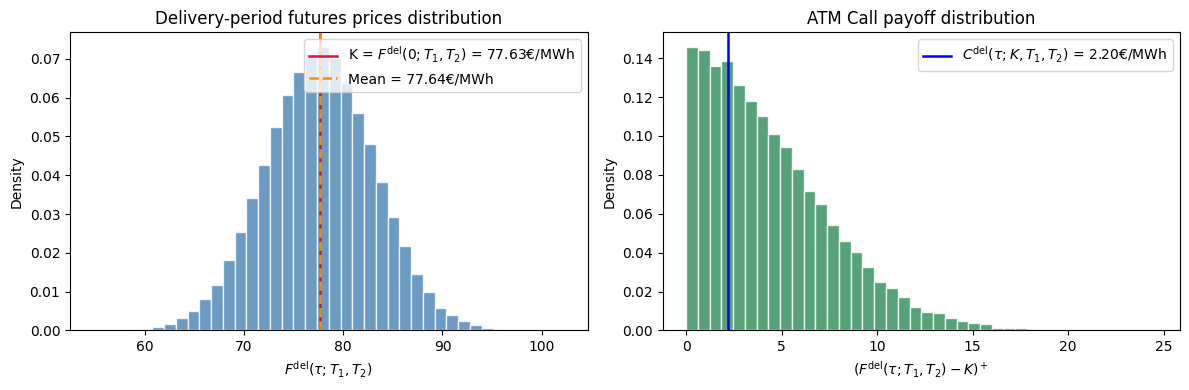

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of Futures prices
axes[0].hist(result['F_del'], bins=40, density=True, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(K, color='crimson', lw=1.8, label=fr'K = $F^{{\rm del}}(0; T_1, T_2)$ = {K:.2f}€/MWh')
axes[0].axvline(result['F_del'].mean(), color='darkorange', lw=1.8, ls='--',
                label=f'Mean = {result["F_del"].mean():.2f}€/MWh')
axes[0].set_xlabel('$F^{\\rm del}(\\tau; T_1, T_2)$')
axes[0].set_ylabel('Density')
axes[0].set_title('Delivery-period futures prices distribution')
axes[0].legend()

# Histogram of payoffs
call_price = result['payoff distribution'].mean()
nonzero = result['payoff distribution'][result['payoff distribution'] > 0]
axes[1].hist(nonzero, bins=40, density=True, color='seagreen', alpha=0.8, edgecolor='white')
axes[1].axvline(call_price,color='blue',lw=1.8,label=fr'$C^{{\rm del}}(\tau; K, T_1, T_2)$ = {call_price:.2f}€/MWh')
axes[1].set_xlabel('$(F^{\\rm del}(\\tau; T_1, T_2) - K)^+$')
axes[1].set_ylabel('Density')
axes[1].set_title('ATM Call payoff distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## Implied NIG-calibration 

1. Define the initial NIG parameters $(\alpha_0, \beta_0, \delta_0, \mu_0)$ under $\mathbb{P}$
2. Precompute $F^{\rm del,(i)}(\alpha_X, \beta_X, \delta_X, \mu_X)$ for each set of parameters (vectorised) and define the objective function (which is the loss to minimize)
3. Build the payoff mean and use `minimize_scalar` on the free parameters $\alpha_X, \beta_X, \delta_X, \mu_X \in (\alpha_{\min}, \alpha_{\max})\bigcup(\beta_{\min}, \beta_{\max})\bigcup(\delta_{\min}, \delta_{\max})\bigcup(\mu_{\min}, \mu_{\max})$ satisfying $|\beta_X|<\alpha_X$ at any time.

**Vectorisation :**  For each quadruplet ($\alpha_X, \beta_X, \delta_X, \mu_X$) visited by the optimiser, and for every
strike $K_j$ simultaneously, the loss is computed with pure array operations.


### Vectorised model prices across all strikes

`delivery_futures` already returns $F^{\rm del,(i)}(\alpha_X, \beta_X, \delta_X)$ for all $N$ paths in one
call ; it does not depend on the strike. We exploit this : for a given triplet, compute
$F_{\rm del}$ **once**, then broadcast against the strike vector $K_j$ in a single array
operation to get all model prices at once.

In [8]:
def model_prices_vectorised(F_del: np.ndarray, strikes: np.ndarray, r: float, tau_hours: float) -> np.ndarray:
    """
    Compute model call prices for ALL strikes simultaneously, given a single set of
    simulated futures F_del and IS weights w_norm (both already evaluated at some vartheta_X).

    Parameters
    F_del     : (N,)  delivery-period futures 
    w_norm    : (N,)  normalised Esscher IS weights
    strikes   : (J,)  strikes K_j
    r         : annual risk-free rate
    tau_hours : option exercise horizon in hours

    Returns
    C_mdl : (J,)  model call price for each strike
    """
    df       = discount_factor(r, tau_hours)
    payoffs  = np.maximum(F_del[:, None] - strikes[None, :], 0.0)   # (N, J)
    C_mdl    = df * payoffs.mean(axis=0)         # (J,)
    return C_mdl

## Pricing test under $\mathbb{P}$ for verification :  Market vs Model prices
### Setting
- Pricing date $T_0$ : 2025-01-31 00:00:00
- Option exercise $\tau$ : 2025-03-01 00:00:00 (1 month maturity)
- Delivery period $[T_1, T_2]$ : March 2025
- Strikes $K_j$ : from **66**€/MWh to **114**€/MWh

49 strikes found for T0=2025-01-31, tau=2025-03-01, delivery=[2025-03-01, 2025-03-31]
    Strike       F  Settlement Price  Model Price
0     66.0  106.26            40.190    20.654536
1     67.0  106.26            39.194    19.654536
2     68.0  106.26            38.199    18.654536
3     69.0  106.26            37.205    17.654536
4     70.0  106.26            36.211    16.654536
5     71.0  106.26            35.219    15.654544
6     72.0  106.26            34.228    14.654579
7     73.0  106.26            33.238    13.654667
8     74.0  106.26            32.251    12.654939
9     75.0  106.26            31.265    11.655685
10    76.0  106.26            30.282    10.657596
11    77.0  106.26            29.302     9.661988
12    78.0  106.26            28.325     8.670681
13    79.0  106.26            27.352     7.687538
14    80.0  106.26            26.384     6.718631
15    81.0  106.26            25.420     5.773012
16    82.0  106.26            24.463     4.862794
17    83.0  10

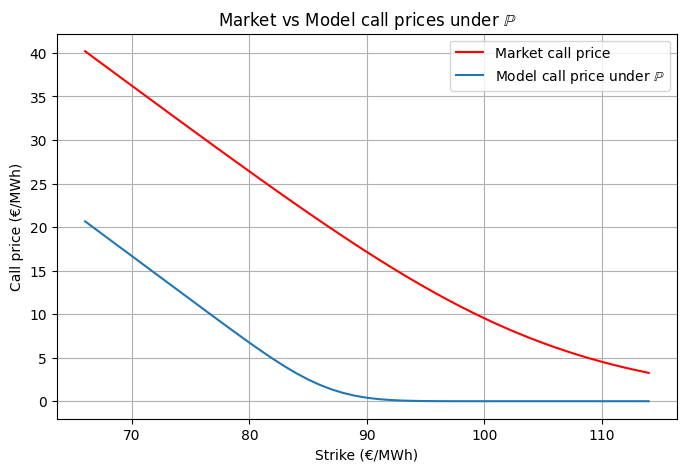

In [40]:
import pyarrow.parquet as pq
import pyarrow.dataset as ds

file_path = r"C:\Users\nolan\PyCharmMiscProject\option_data_DE.parquet"
dataset   = ds.dataset(file_path)

table = dataset.to_table(columns=["Date", "Maturity", "Delivery Start", "Delivery End","Strike", "Settlement Price", "F", "Option Type"])
df_options = table.to_pandas()

# ---------------------------------------------------------------- Fixed parameters
origin_date = pd.Timestamp('2023-01-01 00:00:00')
T0          = pd.Timestamp('2025-01-31') #pricing date
tau         = pd.Timestamp('2025-03-01') #option maturity
T1          = pd.Timestamp('2025-03-01') #delivery start
T2          = pd.Timestamp('2025-03-31') #delivery end
r = 0   
N = 100_000   
tau_hours = int(time_distance(tau, T0))

# ---------------------------------------------------------------- Market slice for these fixed dates
df = df_options[(df_options["Date"] == T0)
                       & (df_options["Maturity"] == tau)
                       & (df_options["Delivery Start"] == T1)
                       & (df_options["Delivery End"] == T2)
                       & (df_options["Option Type"] == 'C')].sort_values('Strike').reset_index(drop=True)

if df.empty:
    raise ValueError('No market data found for the selected (T0, tau, T1, T2) slice.')


strikes = df['Strike'].to_numpy()
C_mkt   = df['Settlement Price'].to_numpy()
F = df['F'].to_numpy()[0]

# ------------------------------------------------------- Model prices
ZX_tau = simulate_state(alpha_0, beta_0, delta_0, mu_0, tau_hours, N, dt=1, seed=0)
F_del = delivery_futures(alpha_0, beta_0, delta_0, mu_0, T1, T2, ZX_tau, 0, T0)
C_mdl = model_prices_vectorised(F_del, strikes, 0, tau_hours)

df["Model Price"] = C_mdl

print(f'{len(strikes)} strikes found for T0={T0.date()}, tau={tau.date()}, 'f'delivery=[{T1.date()}, {T2.date()}]')
print(df[['Strike', 'F', 'Settlement Price', 'Model Price']])

plt.figure(figsize=(8, 5))
plt.plot(strikes, C_mkt, color='red', label='Market call price')
plt.plot(strikes, C_mdl, label='Model call price under $\\mathbb{P}$')
plt.xlabel("Strike (€/MWh)")
plt.ylabel("Call price (€/MWh)")
plt.title("Market vs Model call prices under $\\mathbb{P}$")
plt.legend()
plt.grid(True)
plt.show()

### NIG parameters optimizer on prices
$$\min_{\alpha_X, \beta_X, \delta_X, \mu_X} \sum_j w_j \left(C^{\rm mdl}(K_j, T_1^j, T_2^j; \alpha_X, \beta_X, \delta_X, \mu_X) - C^{\rm mkt}(K_j, T_1^j, T_2^j)\right)^2 \quad \text{s.t.} \quad |\beta_X| < \alpha_X$$


In [18]:
from scipy.optimize import minimize


def calibrate_NIG(
    strikes: np.ndarray,
    C_mkt: np.ndarray,
    T0: pd.Timestamp,
    tau: pd.Timestamp,
    T1: pd.Timestamp,
    T2: pd.Timestamp,
    F_mkt: float,
    weights_mkt: np.ndarray | None = None,
    N: int = 10_000,
    r: float = 0.0,
    dt: float = 1.0,
    seed: int = 0,
    verbose: bool = True
) -> dict:
    """
    Calibrate NIG parameters (alpha_X, beta_X, delta_X, mu_X)
    by minimising the weighted squared error between model and market call prices.
    Re-simulates N paths at each iteration.

    Parameters
    strikes    : (J,)  market strikes
    C_mkt      : (J,)  market call prices
    F_mkt   : float  market forward (from parquet column 'F')
    weights_mkt: (J,)  optional loss weights (default uniform)
    N          : MC paths per evaluation 

    Returns
    dict with keys :
        alpha_X*, beta_X*, delta_X*, mu_X*,
        obj_value, C_mdl_opt, result
    """
    strikes     = np.asarray(strikes,  dtype=float)
    C_mkt       = np.asarray(C_mkt,    dtype=float)
    if weights_mkt is None:
        weights_mkt = np.ones_like(strikes)
    weights_mkt = np.asarray(weights_mkt, dtype=float)

    tau_hours = time_distance(tau, T0)
    tau_years = tau_hours / (365.25 * 24)

    iter_count = [0]
    
    # ---------------------------------------------------------------- Objective
    def objective(params) -> float:                                              #params = np.array([alpha_X, beta_X, delta_X, mu_X])
        iter_count[0] += 1
        
        alpha_X, beta_X, delta_X, mu_X = params[0], params[1], params[2], params[3]        
        #mu_X = solve_mu_X_constraint(alpha_X, beta_X, delta_X, T0, T1, T2, tau_hours, F_target = F_mkt)
        
        if mu_X is None:
            return 1e10
        
        # ---- NIG strip constraint : |beta_Q| < alpha_Q
        if alpha_X <= abs(beta_X) + 1e-6 or delta_X <= 1e-6 or alpha_X <= 1e-6:
            return 1e10

            
        ZX_tau = simulate_state(alpha_X, beta_X, delta_X, mu_X, tau_hours, N, dt=1, seed=0)
        F_del = delivery_futures(alpha_X, beta_X, delta_X, mu_X, T1, T2, ZX_tau, tau_hours, T0)
        F_mean = F_del.mean()
        C_mdl = model_prices_vectorised(F_del, strikes, r, tau_hours)
        
        if not np.all(np.isfinite(C_mdl)):
            return 1e10

        loss = float(np.sum(weights_mkt * (C_mdl - C_mkt) ** 2))

        if verbose:
            print(f'  iter {iter_count[0]:3d} '
                  f'| alpha={alpha_X:.4f} beta={beta_X:+.4f} '
                  f'delta={delta_X:.6f} mu={mu_X:+.6f} '
                  f'| F_mean={F_mean:.2f} | loss={loss:.4e}')
        return loss

    # ---------------------------------------------------------------- Initial P parameters
    x0 = np.array([alpha_0, beta_0, delta_0, mu_0])
    
    # Bounds : NIG strip + positivity
    bounds = [
    (alpha_0 / 3, alpha_0 * 3),
    (-0.95 * alpha_0, 0.95 * alpha_0),
    (-10 * np.abs(delta_0), 10 * np.abs(delta_0)),
    (-10 * np.abs(mu_0), 10 * np.abs(mu_0))]

    if verbose:
        print(f'Calibrating NIG params — {N} paths per eval')
        print(f'x0 = alpha={x0[0]:.4f} beta={x0[1]:+.4f} delta={x0[2]:.6f} mu={x0[3]:+.6f}\n')

    result = minimize(
        objective, x0,
        method  = 'Nelder-Mead',
        bounds  = bounds,
        options = {'xatol'  : 1e-1, 'fatol'  : 1e-4, 'maxiter': 300, 'disp': False})

    alpha_opt, beta_opt, delta_opt, mu_opt = result.x
    #mu_opt = solve_mu_X_constraint(alpha_opt, beta_opt, delta_opt, T0, T1, T2, tau_hours, F_target = F_mkt)

    
    # ---------------------------------------------------------------- Final prices at optimum
    _ = objective(result.x)   

    ZX_tau = simulate_state(alpha_opt, beta_opt, delta_opt, mu_opt, tau_hours, N, dt=1, seed=0)
    F_del_opt = delivery_futures(alpha_opt, beta_opt, delta_opt, mu_opt, T1, T2, ZX_tau, tau_hours, T0)
    F_mean_opt = F_del_opt.mean()
    C_mdl_opt = model_prices_vectorised(F_del_opt, strikes, r, tau_hours)

    # ---------------------------------------------------------------- Display
    if verbose:
        print('\n' + '=' * 65)
        print(f'  alpha_Q* = {alpha_opt:.6f}   (P: {alpha_X:.6f})')
        print(f'  beta_Q*  = {beta_opt:+.6f}   (P: {beta_X:+.6f})')
        print(f'  delta_Q* = {delta_opt:.6f}   (P: {delta_X:.6f})')
        print(f'  mu_Q*    = {mu_opt:+.6f}   (P: {mu_X:+.6f})')
        print(f'  Loss     = {result.fun:.6e}')
        print(f'  F_mean   = {F_mean:.2f}')
        
        print('=' * 65)
        print(f'\n  {"Strike":>10}  {"C_mkt":>10}  {"C_mdl_opt":>10}  {"Error":>10}')
        for K_j, C_mkt_j, C_mdl_j in zip(strikes, C_mkt, C_mdl_opt):
            print(f'  {K_j:10.2f}  {C_mkt_j:10.4f}  {C_mdl_j:10.4f}  '
                  f'{C_mdl_j - C_mkt_j:+10.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(strikes, C_mkt,     'o-',  label='Market $C_{mkt}$')
    plt.plot(strikes, C_mdl_opt, 's--', label='Model $C_{mdl}^{opt}$')
    plt.xlabel('Strike')
    plt.ylabel('Call price')
    plt.title('NIG calibration')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        'alpha_Q'    : alpha_opt,
        'beta_Q'     : beta_opt,
        'delta_Q'    : delta_opt,
        'mu_Q'       : mu_opt,
        'obj_value'  : result.fun,
        'C_mdl_opt'  : C_mdl_opt,
        'result'     : result,
    }

In [19]:
file_path = r"C:\Users\nolan\PyCharmMiscProject\option_data_DE.parquet"
dataset   = ds.dataset(file_path)

table = dataset.to_table(columns=["Date", "Maturity", "Delivery Start", "Delivery End","Strike", "Settlement Price", "F", "Option Type"])
df_options = table.to_pandas()

# ---------------------------------------------------------------- Fixed parameters
origin_date = pd.Timestamp('2023-01-01 00:00:00')
T0          = pd.Timestamp('2025-06-02') #pricing date
tau         = pd.Timestamp('2025-07-01') #option maturity
T1          = pd.Timestamp('2025-07-01') #delivery start
T2          = pd.Timestamp('2025-07-31') #delivery end
r = 0   
N = 100_000   
tau_hours = int(time_distance(tau, T0))

# ---------------------------------------------------------------- Market slice for these fixed dates
df = df_options[(df_options["Date"] == T0)
                & (df_options["Maturity"] == tau)
                & (df_options["Delivery Start"] == T1)
                & (df_options["Delivery End"] == T2)
                & (df_options["Option Type"] == 'C')
                & (df_options["Strike"] >= 80)                 #on optimise que le skew de droite
                ].sort_values('Strike').reset_index(drop=True)

if df.empty:
    raise ValueError('No market data found for the selected (T0, tau, T1, T2) slice.')


# ------------------------------------------------------- Model prices
strikes = df['Strike'].to_numpy()

ZX_tau = simulate_state(alpha_0, beta_0, delta_0, mu_0, tau_hours, N, dt=1, seed=0)
F_del = delivery_futures(alpha_0, beta_0, delta_0, mu_0, T1, T2, ZX_tau, 0, T0)
C_mdl = model_prices_vectorised(F_del, strikes, 0, tau_hours)


C_mkt   = df['Settlement Price'].to_numpy()
F_mkt = df['F'].to_numpy()[0]
df["Model Price"] = C_mdl


# Optimal prices
optimum = calibrate_NIG(strikes = strikes, C_mkt = C_mkt, T0 = T0, tau = tau,  T1 = T1, T2 = T2, F_mkt = F_mkt,
                             N = N, r = r, dt = 1.0, seed = 0, verbose = True)
C_opt = optimum['C_mdl_opt']
df['Optimal Price'] = C_opt

print(f'{len(strikes)} strikes found for T0={T0.date()}, tau={tau.date()}, 'f'delivery=[{T1.date()}, {T2.date()}]')
print(df[['Strike', 'F', 'Settlement Price', 'Model Price', 'Optimal Price']])

plt.figure(figsize=(8, 5))
plt.plot(strikes, C_mkt, color='red', label='Market call price')
plt.plot(strikes, C_mdl, label='Model call price under $\\mathbb{P}$')
plt.plot(strikes, C_opt, color='green', label='Model call price under $\\mathbb{P^*}$')

plt.xlabel("Strike (€/MWh)")
plt.ylabel("Call price (€/MWh)")
plt.title("Market vs Model call prices under both $\\mathbb{P}$ and $\\mathbb{P^*}$")
plt.legend()
plt.grid(True)
plt.show()

Calibrating NIG params — 100000 paths per eval
x0 = alpha=47.4670 beta=-5.0736 delta=0.006870 mu=+0.000740

  iter   1 | alpha=47.4670 beta=-5.0736 delta=0.006870 mu=+0.000740 | F_mean=77.67 | loss=4.6390e+01
  iter   2 | alpha=49.8404 beta=-5.0736 delta=0.006870 mu=+0.000740 | F_mean=78.91 | loss=4.2360e+01
  iter   3 | alpha=47.4670 beta=-5.3273 delta=0.006870 mu=+0.000740 | F_mean=76.30 | loss=5.1077e+01
  iter   4 | alpha=47.4670 beta=-5.0736 delta=0.007214 mu=+0.000740 | F_mean=76.34 | loss=5.0230e+01
  iter   5 | alpha=47.4670 beta=-5.0736 delta=0.006870 mu=+0.000777 | F_mean=78.95 | loss=4.1387e+01
  iter   6 | alpha=48.6537 beta=-4.8199 delta=0.007042 mu=+0.000759 | F_mean=79.68 | loss=3.8565e+01
  iter   7 | alpha=49.2471 beta=-4.5662 delta=0.007128 mu=+0.000768 | F_mean=81.34 | loss=3.3274e+01
  iter   8 | alpha=49.5437 beta=-4.8199 delta=0.006656 mu=+0.000773 | F_mean=81.93 | loss=3.2937e+01
  iter   9 | alpha=50.5821 beta=-4.6931 delta=0.006376 mu=+0.000789 | F_mean=84.55 |

KeyboardInterrupt: 

### To go further :
For each quadruplet $(\alpha_X, \beta_X, \delta_X, \mu_X)$, we add the constraint $$\mathbb{E}[F^{\rm del}(\tau; T_1, T_2)] = F^{mkt}(0; T_1, T_2) \quad \quad \quad (*)$$
However, knowing that $$\mathbb{E}[F^{\rm del}(\tau; T_1, T_2)] = \frac{1}{n} \sum_{j=1}^n \mathbb{E}\left[F(\tau, u_j)\right], \quad n = T_2 -T_1 +1$$
and using the following Lévy's property $$\mathbb{E}\left[\exp\left(i\int_0^{\tau}f(s)dL_s^X\right)\right] = \exp\left(\int_0^{\tau}\psi_X(f(s))ds\right)$$
We can derive the following expression
$$\mathbb{E}[F^{\rm del}(\tau; T_1, T_2)] = \frac{1}{n}\sum_{j=1}^n \exp\left( \Lambda_S(u_j)+\int_0^{u_j}\kappa_X(\beta(s, u_j))ds\right)$$

And since 
$$\kappa_X(u) = u\,\mu_X + \delta_X \,\left( \sqrt{\alpha_X^2 - (\beta_X)^2}-\sqrt{\alpha_X^2 - (\beta_X+u)^2} \right) $$
We get 
$$\mathbb{E}[F^{\rm del}(\tau; T_1, T_2)] = \frac{1}{n}\sum_{j=1}^n \exp\left( \Lambda_S(u_j)+\underline{\mu_X}\left(\int_0^{u_j}\beta(s, u_j)ds\right) + I(\alpha_X, \beta_X, \delta_X)\right)$$
Explicitely,
$$\mathbb{E}[F^{\rm del}(\tau; T_1, T_2)] = \frac{1}{n}\sum_{j=1}^n \exp\left( \Lambda_S(u_j)+\underline{\mu_X}I_1^j + I_2^j\right)$$
The equality is ensured as soon as we choose $\mu_X$ satisfying $(*)$ 

In [81]:
def I_1(u_j_hours: float, tau_hours: float) -> float:
    """
    I_1^j  = int_0^{u_j} beta_X(s, u_j) ds
           = int_0^{u_j} BX' exp(AX*(u_j-s)) cX ds
           = BX' AX^{-1} (exp(AX*u_j) - I) cX (Closed form)
    """
    return float(cX @ np.linalg.inv(AX) @ (expm(AX * u_j_hours) - np.eye(pX)) @ BX)


def I_2(u_j_hours: float, tau_hours: float, alpha_X: float, beta_X: float, delta_X: float) -> float:
    """
    I_2^j = int_0^{u_j} delta_X*(np.sqrt(alpha_X**2 - beta_X**2) - sqrt(alpha_X^2-(beta_X+beta(s,u_j))^2)) ds
    """
    gamma_X = np.sqrt(alpha_X**2 - beta_X**2)

    def integrand(s):
        u = float(cX @ expm(AX * (u_j_hours - s)) @ BX)
        arg = alpha_X**2 - (beta_X + u)**2
        if arg <= 0:
            return np.nan
        return delta_X * (gamma_X - np.sqrt(arg))

    val, _ = quad(integrand, 0, u_j_hours, limit=200)
    return val


def solve_mu_X_constraint(alpha_X: float, beta_X: float, delta_X: float, T0: pd.Timestamp, T1: pd.Timestamp, T2: pd.Timestamp,
                          tau_hours: float, F_target: float, mu_bounds: tuple = (-2.0, 2.0)) -> float | None:
    """
    Find mu_X such that E[F^del(tau; T1, T2)] = F_target
    
    E[F^del] = 1/n sum_j exp(Lambda_S(u_j) + mu_x * I_1(j) + I_2(j))   monotone in mu_Q -> brentq
    """
    delivery_grid = list(pd.date_range(start=T1, end=T2,periods=int(time_distance(T2, T1))))
    n_grid = len(delivery_grid)

    T_h_vec = np.array([time_distance(T_ts, T0) for T_ts in delivery_grid])

    I1 = np.array([I_1(T_h, tau_hours) for T_h in T_h_vec])   # (n,)
    I2  = np.array([I_2(T_h, tau_hours, alpha_X, beta_X, delta_X) for T_h in T_h_vec])                                  # (n,)
    lam_S = np.array([Lambda_S(T_ts) for T_ts in delivery_grid])                                                      # (n,)

    if not np.all(np.isfinite(I2)):
        return None   # NIG strip violated somewhere on the grid

    # base (doesn't depend on mu_X)
    base = lam_S + I2   # (n,)

    def E_F_del(mu: float) -> float:
        """E^Q[F^del] as a function of mu_Q"""
        log_terms = base + mu * I1        # (n,)
        # log-sum-exp for numerical stability
        m = log_terms.max()
        return np.exp(m) * np.mean(np.exp(log_terms - m)) - 1000

    try:
        mu_X = brentq(lambda mu: E_F_del(mu) - F_target, mu_bounds[0], mu_bounds[1], xtol=1e-4, maxiter=100)
        return mu_X
    
    except ValueError:
        try:
            mu_X = brentq(lambda mu: E_F_del(mu) - F_target, -10.0, 10.0, xtol=1e-4, maxiter=200)
            return mu_X
        except ValueError:
            return None

$$\star \star \star$$